### Cleaning and Exploring LC Loan Data

Setting up the Loan Dataset

In [22]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import plotly.express as px

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_fscore_support
import csv

In [3]:
# Reading the main dataset on LC Loans from Kaggle
# The dataset is available at https://www.kaggle.com/datasets/wordsforthewise/lending-club
df = pd.read_csv('C:\Projects\loan.csv')
df.head(5)

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\razor\AppData\Local\Temp\ipykernel_13032\2403707598.py:3: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv('C:\Projects\loan.csv')
C:\Users\razor\AppData\Local\Temp\ipykernel_13032\2403707598.py:3: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\Projects\loan.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Keeping only the columns that are relevant for our analysis  
columns_to_keep = ['loan_amnt', 'int_rate', 'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc', 'loan_status', 'purpose']
loan_df = df[columns_to_keep]

# Calculating loan amount as a percentage of income
loan_df['loan_percent_income'] = loan_df['loan_amnt'] / loan_df['annual_inc']

# Renaming columns for better readability
loan_df.columns = ['loan_amnt', 'loan_int_rate', 'installment', 'loan_grade', 'person_emp_length', 'person_home_ownership', 'person_income', 'loan_status', 'loan_intent', 'loan_percent_income']

# Creating a new column for age based on random values
loan_df['person_age'] = np.random.randint(18, 110, loan_df.shape[0])

# Covertig the loan status to a binary variable
loan_df['loan_status'] = loan_df['loan_status'].map({'Current': 1,'Fully Paid': 1, 'Late (31-120 days)' : 0, 'Charged Off': 0, 'In Grace Period': 0, 'Does not meet the credit policy. Status:Fully Paid': 1, 'Does not meet the credit policy. Status:Charged Off': 0, 'Default': 0})

loan_df.dropna(subset=['loan_status', 'loan_int_rate', 'person_emp_length', 'person_income'], inplace=True)

loan_df['cb_person_cred_hist_length'] = np.random.randint(0, 30, loan_df.shape[0])

# Extracting the number of years from the employment length column
loan_df['person_emp_length'] = loan_df['person_emp_length'].str.extract(r'(\d+)')
loan_df.dropna(subset=['person_emp_length'], inplace=True)
loan_df['person_emp_length'] = loan_df['person_emp_length'].astype(int)

# Use Pandas to drop the record from the data frame and create a new one
loan_df_new = loan_df.drop(loan_df[loan_df['person_income'] > 6*10**8].index)

loan_df_new

C:\Users\razor\AppData\Local\Temp\ipykernel_13032\3862360553.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df['loan_percent_income'] = loan_df['loan_amnt'] / loan_df['annual_inc']
C:\Users\razor\AppData\Local\Temp\ipykernel_13032\3862360553.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_df['person_age'] = np.random.randint(18, 110, loan_df.shape[0])
C:\Users\razor\AppData\Local\Temp\ipykernel_13032\3862360553.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

,loan_amnt,loan_int_rate,installment,loan_grade,person_emp_length,person_home_ownership,person_income,loan_status,loan_intent,loan_percent_income,person_age,cb_person_cred_hist_length
0,2500,13.56,84.92,C,10,RENT,55000.0,1.0,debt_consolidation,0.045455,99,7
1,30000,18.94,777.23,D,10,MORTGAGE,90000.0,1.0,debt_consolidation,0.333333,27,25
2,5000,17.97,180.69,D,6,MORTGAGE,59280.0,1.0,debt_consolidation,0.084345,53,1
3,4000,18.94,146.51,D,10,MORTGAGE,92000.0,1.0,debt_consolidation,0.043478,36,26
4,30000,16.14,731.78,C,10,MORTGAGE,57250.0,1.0,debt_consolidation,0.524017,87,21
...,...,...,...,...,...,...,...,...,...,...,...,...
2260662,30000,30.75,984.47,F,6,MORTGAGE,100000.0,1.0,debt_consolidation,0.300000,22,25
2260663,12000,14.08,279.72,C,10,MORTGAGE,58000.0,1.0,debt_consolidation,0.206897,49,24
2260664,12000,25.82,358.01,E,1,MORTGAGE,30000.0,1.0,debt_consolidation,0.400000,79,27
2260665,10000,11.99,332.10,B,10,OWN,64000.0,1.0,debt_consolidation,0.156250,69,0


In [9]:
num_rows = loan_df['loan_status'].shape[0]
print(f"Number of rows in y_train: {num_rows}")

Number of rows in y_train: 2110451


### Exploring Data

In [38]:
# Checking the structure of the data
print(loan_df.dtypes)

# Checking the first five rows of the data
print(loan_df.head(5))

loan_amnt                       int64
loan_int_rate                 float64
installment                   float64
loan_grade                     object
person_emp_length               int64
person_home_ownership          object
person_income                 float64
loan_status                   float64
loan_intent                    object
loan_percent_income           float64
person_age                      int32
cb_person_cred_hist_length      int32
dtype: object
   loan_amnt  loan_int_rate  installment loan_grade  person_emp_length  \
0       2500          13.56        84.92          C                 10   
1      30000          18.94       777.23          D                 10   
2       5000          17.97       180.69          D                  6   
3       4000          18.94       146.51          D                 10   
4      30000          16.14       731.78          C                 10   

  person_home_ownership  person_income  loan_status         loan_intent  \
0         

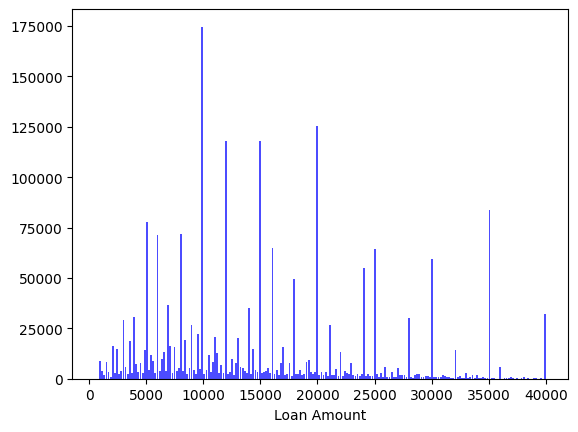

In [39]:
# Looking at the distribution of loan amounts with a histogram
n, bins, patches = plt.hist(x=loan_df['loan_amnt'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("Loan Amount")
plt.show()

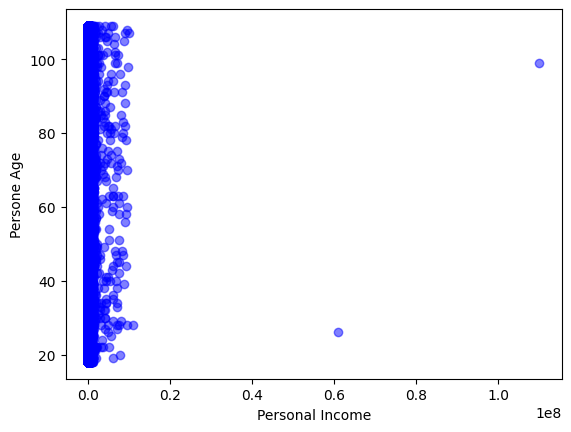

In [40]:
# Plotting a scatter plot of income against age
plt.scatter(loan_df['person_income'], loan_df['person_age'],c='blue', alpha=0.5)
plt.xlabel('Personal Income')
plt.ylabel('Persone Age')
plt.show()

In [41]:
# Creating a cross table of the loan intent and loan status
print(pd.crosstab(loan_df['loan_intent'], loan_df['loan_status'], margins = True))

loan_status            0.0      1.0      All
loan_intent                                 
car                   2162    20260    22422
credit_card          49810   433569   483379
debt_consolidation  166195  1030325  1196520
educational             84      331      415
home_improvement     15598   122656   138254
house                 1667    11432    13099
major_purchase        5675    41561    47236
medical               3295    21527    24822
moving                2211    12117    14328
other                16598   111559   128157
renewable_energy       223     1124     1347
small_business        4855    19071    23926
vacation              1722    12501    14223
wedding                283     2040     2323
All                 270378  1840073  2110451


In [42]:
# Creating a cross table for home ownership and loan status and loan grade
print(pd.crosstab(loan_df['person_home_ownership'], [loan_df['loan_status'], loan_df['loan_grade']]))

loan_status             0.0                                             1.0  \
loan_grade                A      B      C      D      E     F     G       A   
person_home_ownership                                                         
ANY                       2     14     17     13     12     3     2     190   
MORTGAGE               7095  23475  37086  25550  15406  6069  1937  221357   
NONE                      0      4      1      1      0     1     0       6   
OTHER                     2     12      7      7      5     2     3      24   
OWN                    1571   5580   9079   6332   3736  1505   515   41015   
RENT                   5560  23803  40641  29473  16871  6813  2173  128873   

loan_status                                                        
loan_grade                  B       C       D      E      F     G  
person_home_ownership                                              
ANY                       267     199      87     27      6     4  
MORTGAGE        

In [43]:
# Creating a cross table of home ownership, loan status, and average percent income
print(pd.crosstab(loan_df['person_home_ownership'], loan_df['loan_status'],
              values=loan_df['loan_percent_income'], aggfunc='mean'))

loan_status                 0.0       1.0
person_home_ownership                    
ANY                    0.195234  0.213482
MORTGAGE                    inf       inf
NONE                   0.247913  0.279989
OTHER                  0.233355  0.179263
OWN                    0.249924       inf
RENT                        inf       inf


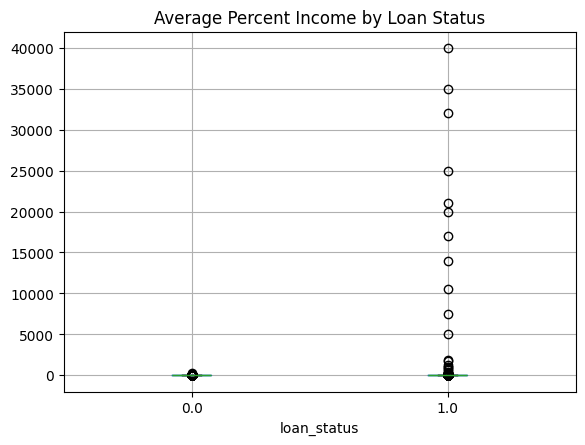

In [44]:
# Creating a box plot of percentage income by loan status
loan_df.boxplot(column = ['loan_percent_income'], by = 'loan_status')
plt.title('Average Percent Income by Loan Status')
plt.suptitle('')
plt.show()

Dealing with Outliers

In [ ]:
# Creating a cross table of home ownership, loan status, and employment length
print(pd.crosstab(loan_df['loan_status'], loan_df['person_home_ownership'],
                  values=loan_df['person_emp_length'], aggfunc=['min', 'max']))

                      min                              max                \
person_home_ownership ANY MORTGAGE NONE OTHER OWN RENT ANY MORTGAGE NONE   
loan_status                                                                
0.0                     1        1    1     1   1    1  10       10   10   
1.0                     1        1    1     1   1    1  10       10   10   

                                      
person_home_ownership OTHER OWN RENT  
loan_status                           
0.0                      10  10   10  
1.0                      10  10   10  


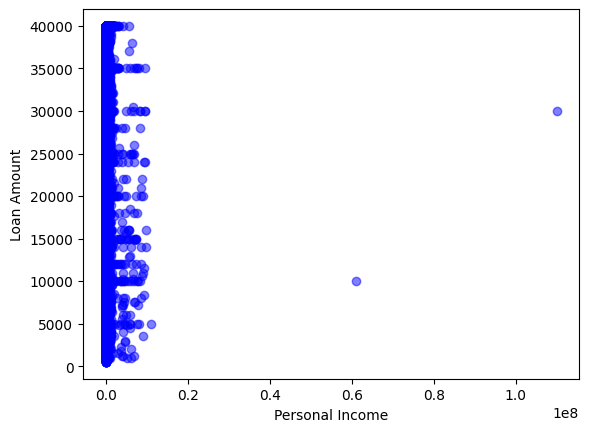

In [ ]:
# Creating the scatter plot for income and loan amount
plt.scatter(loan_df['person_income'], loan_df['loan_amnt'], c='blue', alpha=0.5)
plt.xlabel("Personal Income")
plt.ylabel("Loan Amount")
plt.show()

In [ ]:
# Use Pandas to drop the record from the data frame and create a new one
#loan_df_new = loan_df.drop(loan_df[loan_df['person_income'] > 6*10**8].index)

### Logistic Regression

In [10]:
# Creating the X and y data sets
X = loan_df_new[['loan_int_rate']]
y = loan_df_new[['loan_status']]

# Creating and fittin a logistic regression model
clf_logistic_single = LogisticRegression(solver='lbfgs')
clf_logistic_single.fit(X, np.ravel(y))

# Printing the parameters of the model
print(clf_logistic_single.get_params())

# Printing the intercept of the model
print(clf_logistic_single.intercept_)

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
[3.58498351]


Multivariate Logistic Regression

In [12]:
# Creating X data for the model
X_multi = loan_df_new[['loan_int_rate','person_emp_length']]

# Creating a set of y data for training
y = loan_df_new[['loan_status']]

# Creating and train a new logistic regression
clf_logistic_multi = LogisticRegression(solver='lbfgs').fit(X_multi, np.ravel(y))

# Printing the intercept of the model
print(clf_logistic_multi.intercept_)

[3.54409743]


Creating Training and Testing Datasets

In [ ]:
# Create the X and y data sets
X = loan_df_new[['loan_int_rate','person_emp_length','person_income']]
y = loan_df_new[['loan_status']]

# Use test_train_split to create the training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=123)

# Create and fit the logistic regression model
clf_logistic = LogisticRegression(solver='lbfgs').fit(X_train, np.ravel(y_train))

# Print the models coefficients
print(clf_logistic.coef_)

[[-1.16365246e-01  5.15819967e-03  1.74503321e-06]]


In [16]:
num_rows = y_train.shape[0]
print(f"Number of rows in y_train: {num_rows}")

Number of rows in y_train: 1266270


Getting Dummies for Non-Numeric Data : Loan Grade, Home Ownership, Loan Intent

In [17]:
# Create two data sets for numeric and non-numeric data
cred_num = loan_df_new.select_dtypes(exclude=['object'])
cred_str = loan_df_new.select_dtypes(include=['object'])

# One-hot encode the non-numeric columns
cred_str_onehot = pd.get_dummies(cred_str)

# Union the one-hot encoded columns to the numeric ones
cr_loan_prep = pd.concat([cred_num, cred_str_onehot], axis=1)

# Print the columns in the new data set
print(cr_loan_prep.columns)

Index(['loan_amnt', 'loan_int_rate', 'installment', 'person_emp_length',
       'person_income', 'loan_status', 'loan_percent_income', 'person_age',
       'cb_person_cred_hist_length', 'loan_grade_A', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'person_home_ownership_ANY',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_NONE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_car',
       'loan_intent_credit_card', 'loan_intent_debt_consolidation',
       'loan_intent_educational', 'loan_intent_home_improvement',
       'loan_intent_house', 'loan_intent_major_purchase',
       'loan_intent_medical', 'loan_intent_moving', 'loan_intent_other',
       'loan_intent_renewable_energy', 'loan_intent_small_business',
       'loan_intent_vacation', 'loan_intent_wedding'],
      dtype='object')


Probabilities of Default

In [18]:
# Train the logistic regression model on the training data
clf_logistic = LogisticRegression(solver='lbfgs').fit(X_train, np.ravel(y_train))

# Create predictions of probability for loan status using test data
preds = clf_logistic.predict_proba(X_test)

# Create dataframes of first five predictions, and first five true labels
preds_df = pd.DataFrame(preds[:,1][0:5], columns = ['prob_default'])
true_df = y_test.head(5)

# Concatenate and print the two data frames for comparison
print(pd.concat([true_df.reset_index(drop = True), preds_df], axis = 1))

   loan_status  prob_default
0          1.0      0.905505
1          0.0      0.844343
2          1.0      0.803094
3          1.0      0.892124
4          1.0      0.944717


Default Classification Reporting

In [19]:
# Create a dataframe for the probabilities of default
preds_df = pd.DataFrame(preds[:,1], columns = ['prob_default'])

# Reassign loan status based on the threshold
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Print the row counts for each loan status
print(preds_df['loan_status'].value_counts())

# Print the classification report
target_names = ['Non-Default', 'Default']
print(classification_report(y_test, preds_df['loan_status'], target_names=target_names))

loan_status
1    841954
0      2227
Name: count, dtype: int64
              precision    recall  f1-score   support

 Non-Default       0.33      0.01      0.01    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.60      0.50      0.47    844181
weighted avg       0.80      0.87      0.81    844181



In [23]:
# Print the classification report
target_names = ['Non-Default', 'Default']
print(classification_report(y_test, preds_df['loan_status'], target_names=target_names))

# Print all the non-average values from the report
print(precision_recall_fscore_support(y_test,preds_df['loan_status']))

# Print the first two numbers from the report
print(precision_recall_fscore_support(y_test,preds_df['loan_status'])[0][:2])

              precision    recall  f1-score   support

 Non-Default       0.33      0.01      0.01    107930
     Default       0.87      1.00      0.93    736251

    accuracy                           0.87    844181
   macro avg       0.60      0.50      0.47    844181
weighted avg       0.80      0.87      0.81    844181

(array([0.33004041, 0.87268307]), array([0.00680997, 0.99797352]), array([0.01334459, 0.93113252]), array([107930, 736251]))
[0.33004041 0.87268307]


ROC-AUC Score

0.8712515443962847


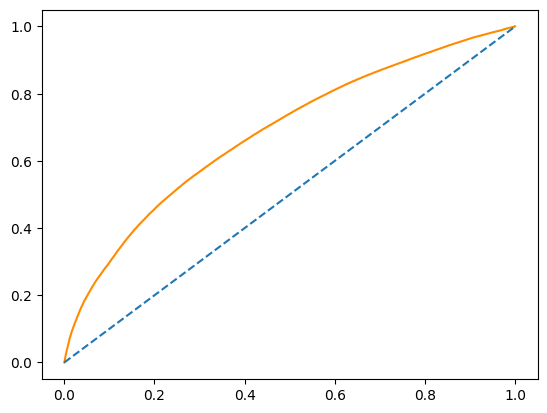

In [24]:
# Create predictions and store them in a variable
preds = clf_logistic.predict_proba(X_test)

# Print the accuracy score the model
print(clf_logistic.score(X_test, y_test))

# Plot the ROC curve of the probabilities of default
prob_default = preds[:, 1]
fallout, sensitivity, thresholds = roc_curve(y_test, prob_default)
plt.plot(fallout, sensitivity, color = 'darkorange')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.show()

# Compute the AUC and store it in a variable
auc = roc_auc_score(y_test, prob_default)

In [25]:
# Set the threshold for defaults to 0.5
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Print the confusion matrix
print(confusion_matrix(y_test, preds_df['loan_status']))

# Set the threshold for defaults to 0.4
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.4 else 0)

# Print the confusion matrix
print(confusion_matrix(y_test, preds_df['loan_status']))

[[   735 107195]
 [  1492 734759]]
[[     0 107930]
 [     0 736251]]


In [28]:
# Reassign the values of loan status based on the new threshold
preds_df['loan_status'] = preds_df['prob_default'].apply(lambda x: 1 if x > 0.5 else 0)

# Store the number of loan defaults from the prediction data
num_defaults = preds_df['loan_status'].value_counts()[1]

# Store the default recall from the classification report
default_recall = precision_recall_fscore_support(y_test, preds_df['loan_status'])[1][1]

avg_loan_amnt = loan_df_new['loan_amnt'].mean()

# Calculate the estimated impact of the new default recall rate
print(avg_loan_amnt * num_defaults * (1 - default_recall))

26014724.449390355
